In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

path_to_data = Path("../data/")
path_to_labels = path_to_data / "labels.csv"

# Load the labels as a DataFrame
df = pd.read_csv(path_to_labels)
df.head(2)

,id,breed,single_dog,multiple_dogs,dog_bounding_boxes
0,000bec180eb18c7604dcecc8fe0dba07,boston_bull,True,False,"[[124.79126739501953, 4.189586639404297, 252.3..."
1,001513dfcb2ffafc82cccf4d8bbaba97,dingo,True,False,"[[83.47296905517578, 33.880210876464844, 371.6..."


In [2]:
single = df.loc[df["single_dog"] == True]
n_singles = len(single)
print(
    f"One dog is visible in {n_singles} ({n_singles/ len(df) * 100:.2f}%) images."
)

One dog is visible in 8573 (83.87%) images.


In [3]:
# Count single-dog images per breed, sorted alphabetically
breed_counts = single["breed"].value_counts().sort_index()
print(breed_counts.to_string())

breed
affenpinscher                      69
afghan_hound                       78
african_hunting_dog                58
airedale                           89
american_staffordshire_terrier     66
appenzeller                        69
australian_terrier                 91
basenji                            85
basset                             70
beagle                             97
bedlington_terrier                 81
bernese_mountain_dog              103
black-and-tan_coonhound            70
blenheim_spaniel                   86
bloodhound                         75
bluetick                           76
border_collie                      67
border_terrier                     79
borzoi                             62
boston_bull                        72
bouvier_des_flandres               63
boxer                              71
brabancon_griffon                  65
briard                             52
brittany_spaniel                   71
bull_mastiff                       61
cairn 

In [4]:
# Check if any breed is entirely absent from single-dog images
all_breeds = set(df["breed"].unique())
single_breeds = set(single["breed"].unique())
missing = all_breeds - single_breeds
print(f"Breeds with no single_dog=True rows: {missing if missing else 'None'}")

Breeds with no single_dog=True rows: None


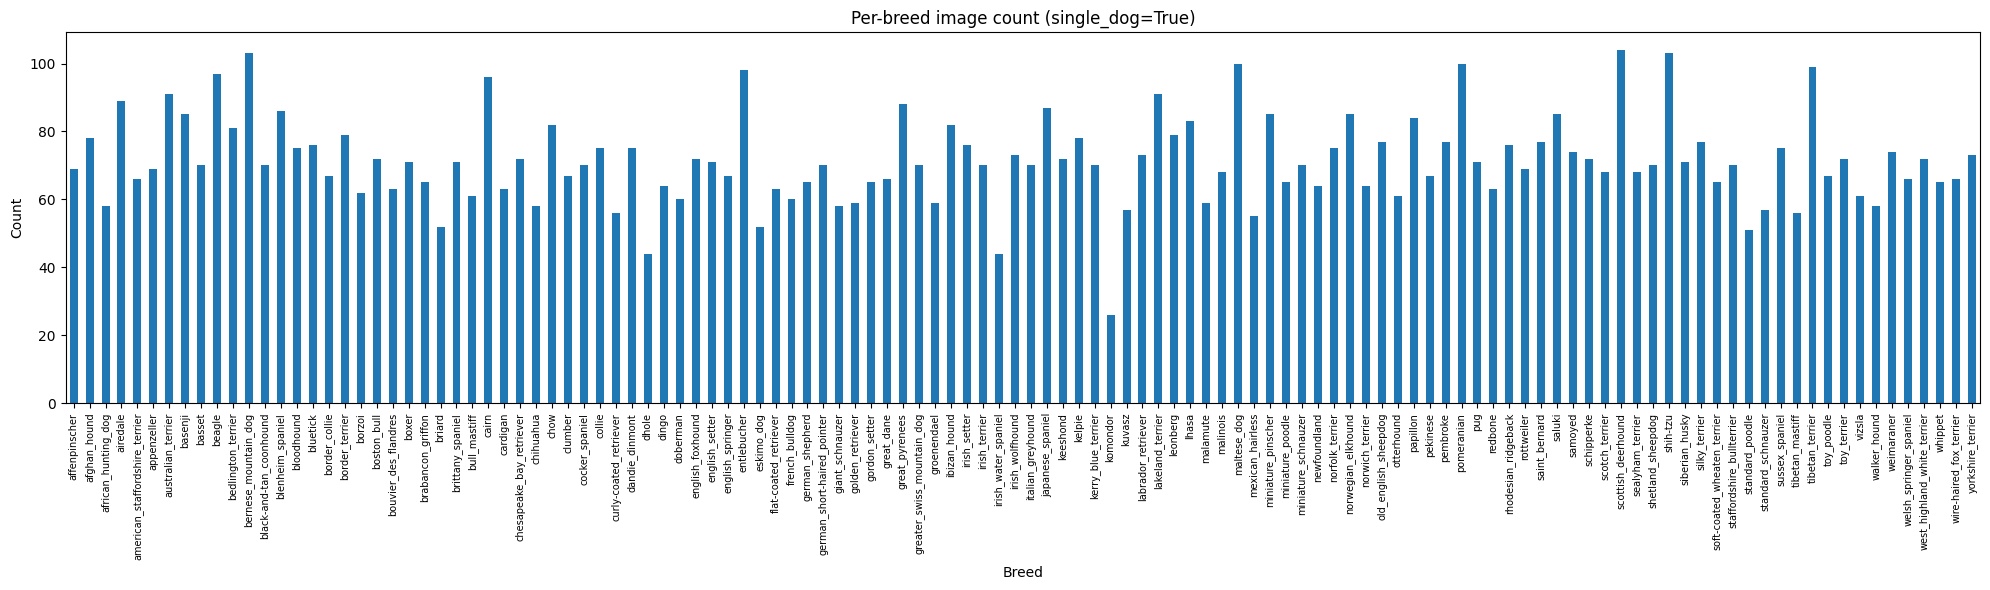

In [5]:
# Bar chart of per-breed image counts for single-dog images
fig, ax = plt.subplots(figsize=(20, 6))
breed_counts.plot(kind="bar", ax=ax)
ax.set_title("Per-breed image count (single_dog=True)")
ax.set_xlabel("Breed")
ax.set_ylabel("Count")
plt.xticks(rotation=90, fontsize=7)
plt.tight_layout()
plt.show()

In [6]:
# Summary statistics: distribution spread and extreme breeds
print(breed_counts.describe())
print(f"\nLowest:  {breed_counts.idxmin()} ({breed_counts.min()})")
print(f"Highest: {breed_counts.idxmax()} ({breed_counts.max()})")

count    120.000000
mean      71.441667
std       12.895049
min       26.000000
25%       64.000000
50%       70.000000
75%       77.000000
max      104.000000
Name: count, dtype: float64

Lowest:  komondor (26)
Highest: scottish_deerhound (104)


In [7]:
# Check bounding box completeness
null_mask  = df["dog_bounding_boxes"].isna()
empty_mask = df["dog_bounding_boxes"].eq("") | df["dog_bounding_boxes"].eq("[]")
problem_mask = null_mask | empty_mask

print(f"Null values:              {null_mask.sum()}")
print(f"Empty string / '[]':      {empty_mask.sum()}")
print(f"Total missing bbox rows:  {problem_mask.sum()} / {len(df)}")
if problem_mask.any():
    print("\nSample problem rows:")
    print(df[problem_mask][["id", "breed", "single_dog", "multiple_dogs", "dog_bounding_boxes"]].head(10).to_string())

Null values:              0
Empty string / '[]':      548
Total missing bbox rows:  548 / 10222

Sample problem rows:
                                   id                    breed  single_dog  multiple_dogs dog_bounding_boxes
15   00792e341f3c6eb33663e415d0715370      african_hunting_dog       False          False                 []
16   007b5a16db9d9ff9d7ad39982703e429  wire-haired_fox_terrier       False          False                 []
42   011e06760794850c40f23d6426c40774                    dhole       False          False                 []
49   0140b05bfc2fd43f2819fab3d8566109       norwegian_elkhound       False          False                 []
50   014c2b0cd8e3b517e649cecf8543b8fe      african_hunting_dog       False          False                 []
51   0159b6457aac89f43d1c1931cdf7500b      irish_water_spaniel       False          False                 []
64   019c92d1ff56deb9d75d809a92bc84d8               schipperke       False          False                 []
87   0214e

## Cropped Images Dataset

In [ ]:
path_to_cropped_labels = path_to_data / "cropped_image_labels.csv"
crops = pd.read_csv(path_to_cropped_labels)
print(f"Total cropped images: {len(crops)}")
crops.head(2)

In [ ]:
crop_breed_counts = crops["breed"].value_counts().sort_index()
print(crop_breed_counts.to_string())

In [ ]:
all_breeds = set(df["breed"].unique())
crop_breeds = set(crops["breed"].unique())
missing = all_breeds - crop_breeds
print(f"Breeds with no cropped images: {missing if missing else 'None'}")

In [ ]:
fig, ax = plt.subplots(figsize=(20, 6))
crop_breed_counts.plot(kind="bar", ax=ax)
ax.set_title("Per-breed cropped image count")
ax.set_xlabel("Breed")
ax.set_ylabel("Count")
plt.xticks(rotation=90, fontsize=7)
plt.tight_layout()
plt.show()

In [ ]:
print(crop_breed_counts.describe())
print(f"\nLowest:  {crop_breed_counts.idxmin()} ({crop_breed_counts.min()})")
print(f"Highest: {crop_breed_counts.idxmax()} ({crop_breed_counts.max()})")